<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


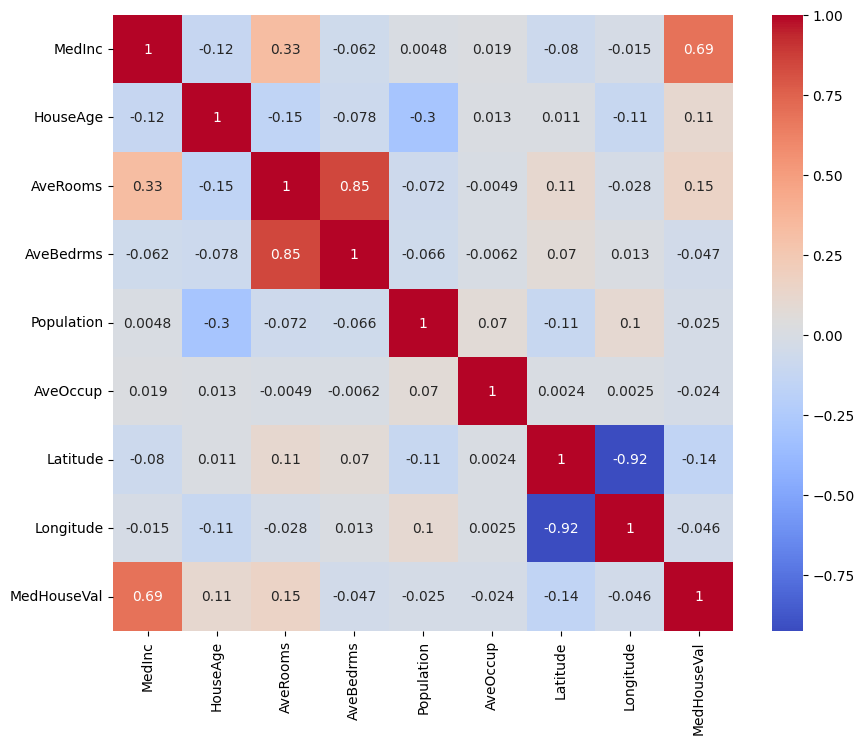


MAE : 0.5239
MSE : 0.5159
RMSE: 0.7183
R²  : 0.6307


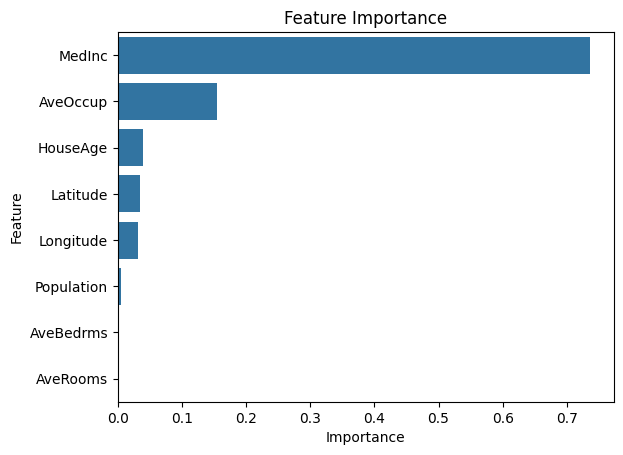

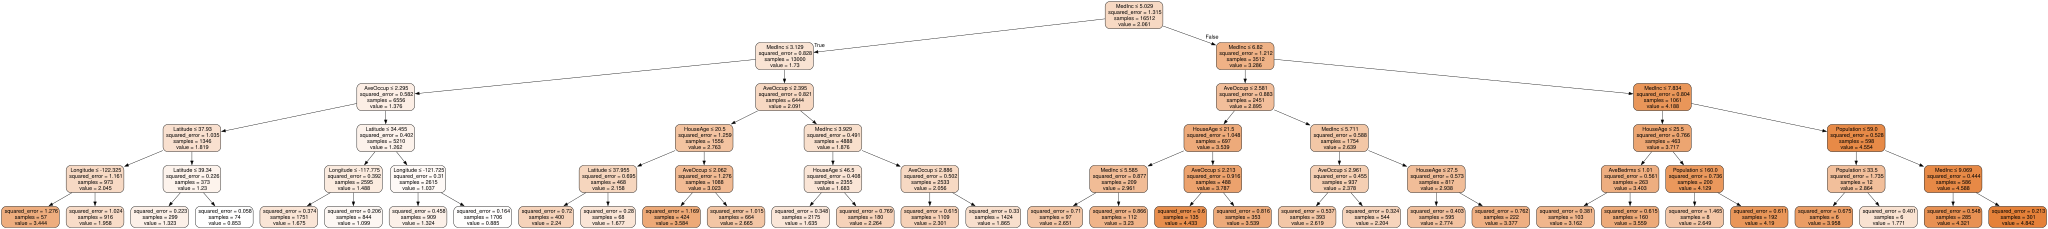

In [1]:
# =============================================================================
# SECTION 1: DATA PREP, EDA & BASELINE DECISION TREE REGRESSION
# Run this cell to get ALL outputs for the Decision Tree Regression section together.
# =============================================================================

# --- 1.1 Import libraries ---
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline

# --- 1.2 Load California Housing dataset ---
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
housing = california.frame

housing.head()

# --- 1.3 Basic EDA ---
housing.shape
housing.info()
housing.head()
housing.describe()
housing.isna().sum()

# --- 1.4 Correlation Heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm')
plt.show()

# --- 1.5 Import sklearn ---
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor

# --- 1.6 Create features and target ---
x = housing.drop('MedHouseVal', axis=1)
y = housing['MedHouseVal']

x.shape
print()
y.shape

# --- 1.7 Train/Test Split ---
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=999
)

x_train.shape
y_train.shape
x_test.shape
y_test.shape

# --- 1.8 Create Baseline Decision Tree Regressor ---
mytree = DecisionTreeRegressor(
    random_state=99,
    criterion='squared_error',
    max_depth=5
)

mytree

# --- 1.9 Train Model ---
mytree.fit(x_train, y_train)

# --- 1.10 Predict ---
predicted = mytree.predict(x_test)

predicted[:10]

# --- 1.11 Evaluate Model ---
mae = metrics.mean_absolute_error(y_test, predicted)
mse = metrics.mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predicted)

print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

# --- 1.12 Feature Importance ---
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': mytree.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance")
plt.show()

# --- 1.13 Tree Visualization ---
from sklearn import tree
import graphviz

dot_data = tree.export_graphviz(
    mytree,
    out_file=None,
    feature_names=x.columns,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph

In [2]:
# =============================================================================
# SECTION 2: CROSS-VALIDATION (Decision Tree Regression)
# Requires Section 1 to be run first (mytree, x_train, y_train).
# =============================================================================

from sklearn.model_selection import cross_val_score

# --- 2.1 Cross-validation using MAE ---
scores_mae = cross_val_score(
    mytree,
    x_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

print("MAE for each fold:")
print(-scores_mae)

print("\nAverage MAE:")
print(round(-scores_mae.mean(), 4))

print("\nStandard Deviation:")
print(round(scores_mae.std(), 4))

MAE for each fold:
[0.51322582 0.53039998 0.51850597 0.51858274 0.50602911]

Average MAE:
0.5173

Standard Deviation:
0.008


In [5]:
# =============================================================================
# SECTION 3: HYPERPARAMETER OPTIMIZATION (GridSearchCV — Decision Tree Regression)
# Requires Section 1 to be run first.
# =============================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
import pandas as pd
import numpy as np

# --- 3.1 Reset tree for tuning ---
mytree = DecisionTreeRegressor(random_state=99)

mytree

# --- 3.2 Define hyperparameter search space ---
param_grid = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 10, 20],
    'ccp_alpha': [0.0, 0.001]
}

# Display total number of parameter combinations
total_models = np.prod([len(v) for v in param_grid.values()])
print(f"Total Parameter Combinations: {total_models}")

# --- 3.3 Build GridSearchCV ---
grid = GridSearchCV(
    estimator=mytree,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid

# --- 3.4 Fit on training data ---
grid.fit(x_train, y_train)

# --- 3.5 Best model results ---
print("\nBest Hyperparameters:")
print(grid.best_params_)

print("\nBest Cross-Validation MAE:")
print(round(-grid.best_score_, 4))

print("\nFeature Importances:")
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': grid.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# Save complete CV results
results = pd.DataFrame(grid.cv_results_)
results.to_csv("results.csv", index=False)

# --- 3.6 Evaluate tuned model on test set ---
best_model = grid.best_estimator_

predicted = best_model.predict(x_test)

mae = metrics.mean_absolute_error(y_test, predicted)
mse = metrics.mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predicted)

print("\nTest Set Performance")
print("--------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",99
,"max_l

Total Parameter Combinations: 144


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0, 0.001], 'criterion': ['squared_error', 'absolute_error'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0, 0.001], 'criterion': ['squared_error', 'absolute_error'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp


Best Hyperparameters:
{'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best Cross-Validation MAE:
0.3953

Feature Importances:
      Feature  Importance
0      MedInc    0.476261
7   Longitude    0.157283
6    Latitude    0.133239
5    AveOccup    0.118970
2    AveRooms    0.043280
1    HouseAge    0.041190
3   AveBedrms    0.015253
4  Population    0.014525

Test Set Performance
--------------------
MAE  : 0.3871
MSE  : 0.3701
RMSE : 0.6083
R²   : 0.7351


In [6]:
# =============================================================================
# SECTION 4: PREDICTION ANALYSIS
# Requires Section 3 to be run first (grid).
# =============================================================================

# --- 4.1 Predict using the best model ---
predicted = grid.predict(x_test)

# --- 4.2 Create comparison DataFrame ---
predicted_df = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': predicted
})

# --- 4.3 Calculate errors ---
predicted_df['Absolute_Error'] = abs(
    predicted_df['Actual_Value'] - predicted_df['Predicted_Value']
)

predicted_df['Residual'] = (
    predicted_df['Actual_Value'] - predicted_df['Predicted_Value']
)

# --- 4.4 Display sample predictions ---
predicted_df.sample(20)

# --- 4.5 Summary statistics of prediction errors ---
predicted_df.describe()

,Actual_Value,Predicted_Value,Absolute_Error,Residual
3168,4.20000,1.7940,2.40600,2.40600
582,2.60500,2.3360,0.26900,0.26900
13,2.19000,1.5450,0.64500,0.64500
304,4.83300,3.2590,1.57400,1.57400
1642,2.68100,2.1730,0.50800,0.50800
3339,1.46900,1.2500,0.21900,0.21900
1178,2.13500,1.0260,1.10900,1.10900
3641,1.26600,1.1230,0.14300,0.14300
3026,1.42100,1.3895,0.03150,0.03150
275,1.61300,1.6545,0.04150,-0.04150


,Actual_Value,Predicted_Value,Absolute_Error,Residual
count,4128.000000,4128.000000,4128.000000,4128.000000
mean,2.098513,2.052144,0.387105,0.046368
std,1.182112,1.098230,0.469334,0.606639
min,0.149990,0.445000,0.000000,-3.152000
25%,1.194000,1.234000,0.086000,-0.206125
50%,1.821000,1.806250,0.227250,0.000000
75%,2.693250,2.610500,0.507125,0.252500
max,5.000010,5.000010,4.008510,4.008510


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Actual House Value')

Text(0, 0.5, 'Predicted House Value')

Text(0.5, 1.0, 'Actual vs Predicted')

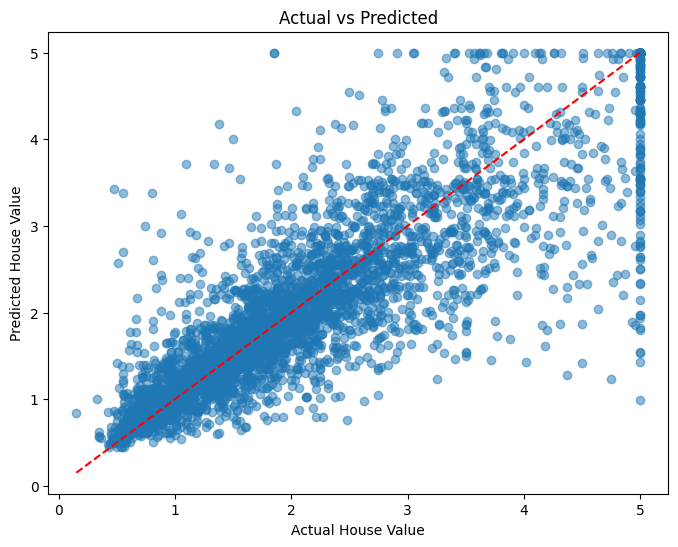

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='MedHouseVal', ylabel='Count'>

Text(0.5, 1.0, 'Residual Distribution')

Text(0.5, 0, 'Residual')

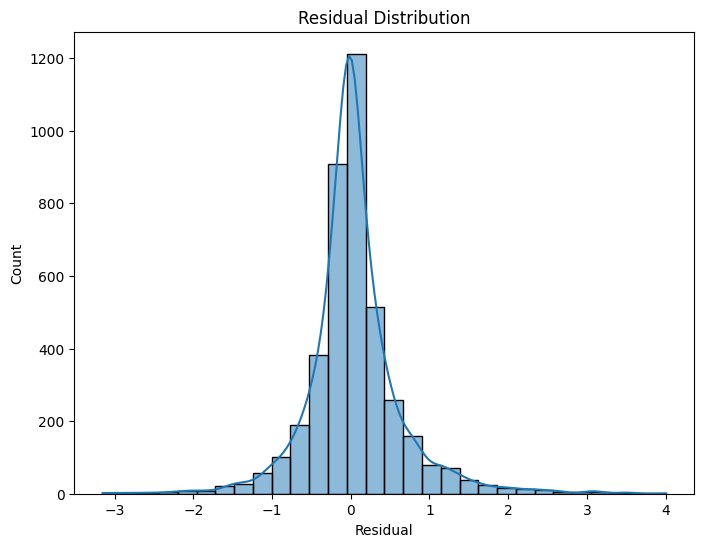

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Predicted House Value')

Text(0, 0.5, 'Residual')

Text(0.5, 1.0, 'Residuals vs Predicted Values')

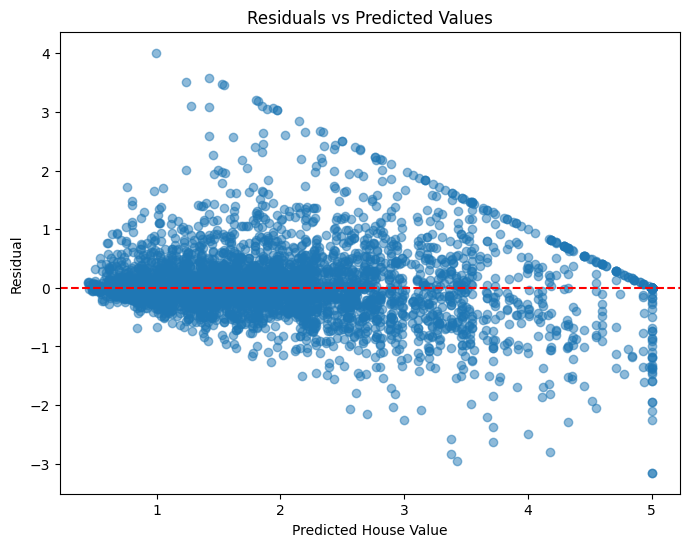

Final Model Performance
-----------------------
MAE : 0.3871
MSE : 0.3701
RMSE: 0.6083
R²  : 0.7351


In [7]:
# =============================================================================
# SECTION 5: MODEL PERFORMANCE & RESIDUAL ANALYSIS
# Requires Section 3 and Section 4 to be run first.
# =============================================================================

# --- 5.1 Calculate residuals ---
residuals = y_test - predicted

# --- 5.2 Actual vs Predicted Scatter Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_test, predicted, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")
plt.show()

# --- 5.3 Residual Distribution ---
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

# --- 5.4 Residuals vs Predicted Values ---
plt.figure(figsize=(8,6))
plt.scatter(predicted, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

# --- 5.5 Final Evaluation Metrics ---
mae = metrics.mean_absolute_error(y_test, predicted)
mse = metrics.mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predicted)

print("Final Model Performance")
print("-----------------------")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")